Precomputing vectors and sums:   0%|          | 0/2000 [00:00<?, ?it/s]

Rendering frames:   0%|          | 0/2000 [00:00<?, ?it/s]

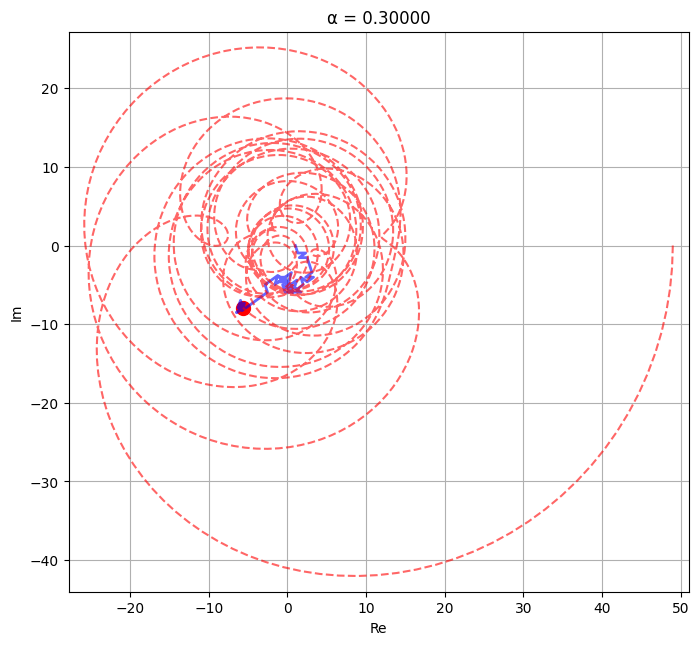

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from sympy.functions.combinatorial.numbers import totient
from tqdm.notebook import tqdm

# Parameters
n = 50
num_alpha = 2000
fps = 10  # slow playback
alpha_max = 0.3  # short range

alphas = np.linspace(0, alpha_max, num_alpha)

# Precompute everything
all_sums = []
all_vectors = []

for alpha in tqdm(alphas, desc="Precomputing vectors and sums"):
    vectors = []
    for c in range(0, n - 1):
        phi1 = totient(n + c)
        phi2 = totient(n - c)
        total_phi = int(phi1 + phi2)
        angle = -2 * np.pi * total_phi * alpha
        vectors.append(np.exp(1j * angle))
    path = np.cumsum(vectors)
    all_vectors.append(path)
    all_sums.append(path[-1])

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('Re')
ax.set_ylabel('Im')

# Set limits
real_vals = [z.real for z in all_sums]
imag_vals = [z.imag for z in all_sums]
margin = 2
ax.set_xlim(min(real_vals) - margin, max(real_vals) + margin)
ax.set_ylim(min(imag_vals) - margin, max(imag_vals) + margin)

# Plot elements
(sum_point,) = ax.plot([], [], 'ro', markersize=10)
(path_line,) = ax.plot([], [], 'b-', lw=2, alpha=0.6)
(trail_line,) = ax.plot([], [], 'r--', lw=1.5, alpha=0.6)

pbar = tqdm(total=len(alphas), desc="Rendering frames", position=0)
def update(frame):
    vecs = all_vectors[frame]
    z = all_sums[frame]

    path_line.set_data(vecs.real, vecs.imag)
    sum_point.set_data([z.real], [z.imag])

    # Trail of sum positions
    trail = all_sums[:frame + 1]
    trail_x = [pt.real for pt in trail]
    trail_y = [pt.imag for pt in trail]
    trail_line.set_data(trail_x, trail_y)

    ax.set_title(f"α = {alphas[frame]:.5f}")
    pbar.update(1)
    return sum_point, path_line, trail_line


# Animation
anim = FuncAnimation(fig, update, frames=len(
    alphas), interval=1000 // fps, blit=True)

# Save
writer = FFMpegWriter(fps=fps)
anim.save("totient_sum_zoomed_animation.mp4", writer=writer)

plt.show()
pbar.close()